In [1]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Kunny\Documents\GitHub\CAGI\EvoStructCLIP\FireProtDB\fireprotdb_ddg_final_all_ver2.csv", low_memory=False)

In [2]:
df

,PROTEIN_ID,WT,POS,MUT,DDG_mean,SOURCE_DATASET,UNIPROTKB,PDB_ID,MEGASCALE
0,1A0N,A,12,C,-1.271679,MegaScale,NaN,NaN,1A0N
1,1A0N,A,12,D,-2.513681,MegaScale,NaN,NaN,1A0N
2,1A0N,A,12,E,-2.120722,MegaScale,NaN,NaN,1A0N
3,1A0N,A,12,F,-2.238222,MegaScale,NaN,NaN,1A0N
4,1A0N,A,12,G,-0.142810,MegaScale,NaN,NaN,1A0N
...,...,...,...,...,...,...,...,...,...
347020,v2_6IVS,Y,7,R,0.056541,MegaScale,NaN,NaN,v2_6IVS
347021,v2_6IVS,Y,7,S,-0.514305,MegaScale,NaN,NaN,v2_6IVS
347022,v2_6IVS,Y,7,T,-0.211927,MegaScale,NaN,NaN,v2_6IVS
347023,v2_6IVS,Y,7,V,-0.062451,MegaScale,NaN,NaN,v2_6IVS


In [3]:
df_uni = df[df["SOURCE_DATASET"]!="MegaScale"].copy()
df_mega = df[df["SOURCE_DATASET"]=="MegaScale"].copy()

In [4]:
df_uni

,PROTEIN_ID,WT,POS,MUT,DDG_mean,SOURCE_DATASET,UNIPROTKB,PDB_ID,MEGASCALE
300578,O26594,V,92,L,1.100000,ProTherm,O26594,NaN,NaN
300579,O49003,C,450,A,-0.480000,ProTherm,O49003,2V0U,NaN
300580,O61594,A,263,F,0.430000,ProTherm,O61594,5CG0,NaN
300581,O61594,D,260,A,0.670000,ProTherm,O61594,5CG0,NaN
300582,O61594,E,261,A,-0.530000,ProTherm,O61594,5CG0,NaN
...,...,...,...,...,...,...,...,...,...
306067,R9S082,T,68,A,0.300000,ProTherm,R9S082,NaN,NaN
306068,R9S082,V,115,A,1.400000,ProTherm,R9S082,NaN,NaN
306069,R9S082,V,14,A,0.000000,ProTherm,R9S082,NaN,NaN
306070,R9S082,V,69,T,0.400000,ProTherm,R9S082,NaN,NaN


In [5]:
import pandas as pd
import requests
import os

In [6]:
# 1. UNIPROTKB에서 첫 번째 ID만 추출
df_uni['UP_ID_CLEAN'] = df_uni['UNIPROTKB'].str.split(',').str[0].str.strip()

# 2. 고유한 (UniProt ID, PDB_ID) 쌍 추출 (효율적인 루프를 위해)
unique_targets = df_uni[['UP_ID_CLEAN', 'PDB_ID']].drop_duplicates().reset_index(drop=True)

print(f"전체 로우: {len(df_uni)} -> 처리할 유니크 타겟: {len(unique_targets)}")

전체 로우: 4350 -> 처리할 유니크 타겟: 182


In [7]:
def download_pdb(uniprot_id, pdb_id, save_dir="./pdb_files"):
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    
    # 결과 저장용 변수
    source = None
    file_path = None

    # 2. AlphaFold DB 시도 (UniProt ID 기반)
    af_url = f"https://alphafold.ebi.ac.uk/api/prediction/{uniprot_id}"
    try:
        res = requests.get(af_url).json()
        if res and len(res) > 0:
            # 가장 최신 entry의 pdb url 가져오기
            pdb_url = res[0]['pdbUrl']
            file_path = os.path.join(save_dir, f"{uniprot_id}_AF.pdb")
            pdb_content = requests.get(pdb_url).text
            with open(file_path, 'w') as f:
                f.write(pdb_content)
            return uniprot_id, "AlphaFold", file_path
    except:
        pass
    
    # 1. RCSB PDB 시도 (PDB_ID가 존재할 때)
    if pd.notna(pdb_id) and pdb_id != 'NaN':
        pdb_url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
        try:
            res = requests.get(pdb_url)
            if res.status_code == 200:
                file_path = os.path.join(save_dir, f"{pdb_id}.pdb")
                with open(file_path, 'w') as f:
                    f.write(res.text)
                return pdb_id, "RCSB_PDB", file_path
        except:
            pass
        
    return None, "Failed", None

In [8]:
results = []

for idx, row in unique_targets.iterrows():
    up_id = row['UP_ID_CLEAN']
    pdb_id = row['PDB_ID']
    
    print(f"[{idx+1}/{len(unique_targets)}] Processing: {up_id}...", end='\r')
    
    found_id, source, path = download_pdb(up_id, pdb_id)
    results.append({
        'UP_ID_CLEAN': up_id,
        'PDB_ID': pdb_id,
        'FETCHED_ID': found_id,
        'STRUCTURE_SOURCE': source,
        'FILE_PATH': path
    })

# 결과를 데이터프레임으로 변환 후 병합
df_results = pd.DataFrame(results)
df_final = pd.merge(df_uni, df_results, on=['UP_ID_CLEAN', 'PDB_ID'], how='left')

 [ 수집 결과 요약 ]
      Source  Count  Percentage (%)
0  AlphaFold    169           92.86
1   RCSB_PDB      8            4.40
2     Failed      5            2.75
------------------------------
총 고유 ID 개수: 182
성공: 177 (97.25%)
실패: 5 (2.75%)


C:\Users\Kunny\AppData\Local\Temp\ipykernel_14076\3088962862.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=source_stats, x='Source', y='Count', palette='viridis')


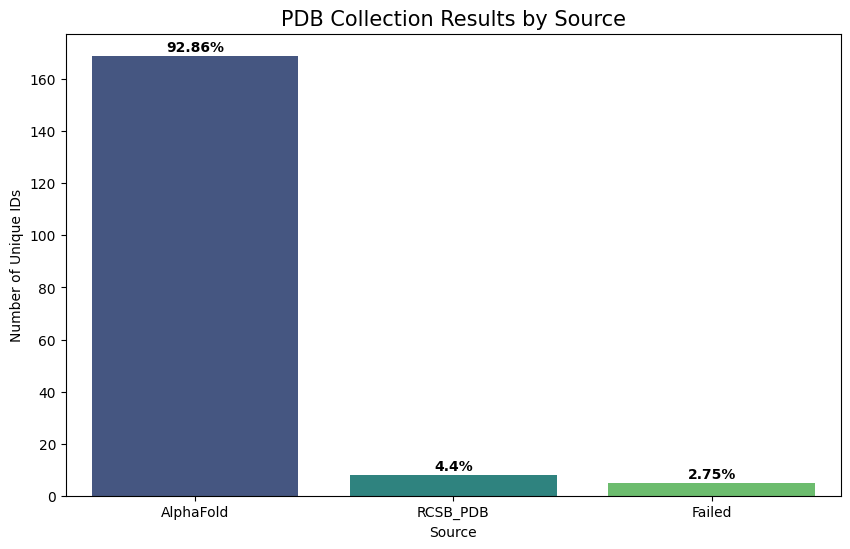


 [ 실패한 UniProt ID (상위 10개) ]
['P00720', 'P01607', 'P03040', 'P03050', 'P69542']


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 소스별 수량 및 비율 계산
source_stats = df_results['STRUCTURE_SOURCE'].value_counts().reset_index()
source_stats.columns = ['Source', 'Count']
source_stats['Percentage (%)'] = (source_stats['Count'] / len(df_results) * 100).round(2)

print(" [ 수집 결과 요약 ]")
print(source_stats)
print("-" * 30)

# 2. 성공률 계산
total = len(df_results)
success = len(df_results[df_results['STRUCTURE_SOURCE'] != 'Failed'])
fail = total - success
print(f"총 고유 ID 개수: {total}")
print(f"성공: {success} ({success/total*100:.2f}%)")
print(f"실패: {fail} ({fail/total*100:.2f}%)")

# 3. 시각화 (막대 그래프)
plt.figure(figsize=(10, 6))
sns.barplot(data=source_stats, x='Source', y='Count', palette='viridis')
plt.title('PDB Collection Results by Source', fontsize=15)
for i, row in source_stats.iterrows():
    plt.text(i, row['Count'] + (total*0.01), f"{row['Percentage (%)']}%", ha='center', fontweight='bold')
plt.ylabel('Number of Unique IDs')
plt.show()

# 4. 실패한 리스트 따로 뽑아보기 (원인 분석용)
failed_df = df_results[df_results['STRUCTURE_SOURCE'] == 'Failed']
if not failed_df.empty:
    print("\n [ 실패한 UniProt ID (상위 10개) ]")
    print(failed_df['UP_ID_CLEAN'].head(10).tolist())

In [10]:
from Bio.PDB import PDBParser
from Bio.PDB.Polypeptide import three_to_one, is_aa

def verify_with_chain_mapping(row):
    if pd.isna(row['FILE_PATH']) or row['STRUCTURE_SOURCE'] == 'Failed':
        return "No_File", None
    
    up_id = row['UP_ID_CLEAN']
    target_pos = int(row['POS'])
    target_wt = row['WT']
    
    try:
        parser = PDBParser(QUIET=True)
        structure = parser.get_structure('protein', row['FILE_PATH'])
        model = structure[0]
        
        # 1. PDB 파일 헤더에서 UniProt ID와 매핑된 체인 찾기
        # (AlphaFold는 보통 헤더가 없으므로 별도 처리)
        matched_chains = []
        
        if row['STRUCTURE_SOURCE'] == 'RCSB_PDB':
            header = parser.get_header()
            # DBREF 정보를 통해 UniProt ID와 연결된 체인 리스트 추출
            # Biopython의 header 파싱은 제한적이므로, 체인을 직접 돌며 검증하는 것이 더 확실할 수 있음
            pass 

        # 2. 모든 체인을 검사하되, UniProt ID와 매핑 여부를 확인
        for chain in model:
            # 해당 위치에 잔기가 있는지 확인
            if target_pos in chain:
                res = chain[target_pos]
                if is_aa(res):
                    res_name_1 = three_to_one(res.get_resname())
                    
                    # WT가 일치하는 체인을 찾으면 즉시 반환
                    if res_name_1 == target_wt:
                        return "Match", chain.id
        
        return "Mismatch_or_Not_Found", None
        
    except Exception as e:
        return f"Error: {str(e)}", None

# 적용 (결과가 2개이므로 zip 사용)
print("정밀 체인 매핑 시작...")
results = df_final.apply(verify_with_chain_mapping, axis=1)
df_final[['MAPPING_STATUS', 'MATCHED_CHAIN']] = pd.DataFrame(results.tolist(), index=df_final.index)

정밀 체인 매핑 시작...


=== [ 매핑 실패 원인 통계 ] ===
          Failure_Reason  Count  Percentage (%)
0                No_File    402           91.99
1  Mismatch_or_Not_Found     35            8.01
----------------------------------------


C:\Users\Kunny\AppData\Local\Temp\ipykernel_14076\4124096881.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fail_stats, x='Failure_Reason', y='Count', palette='magma')


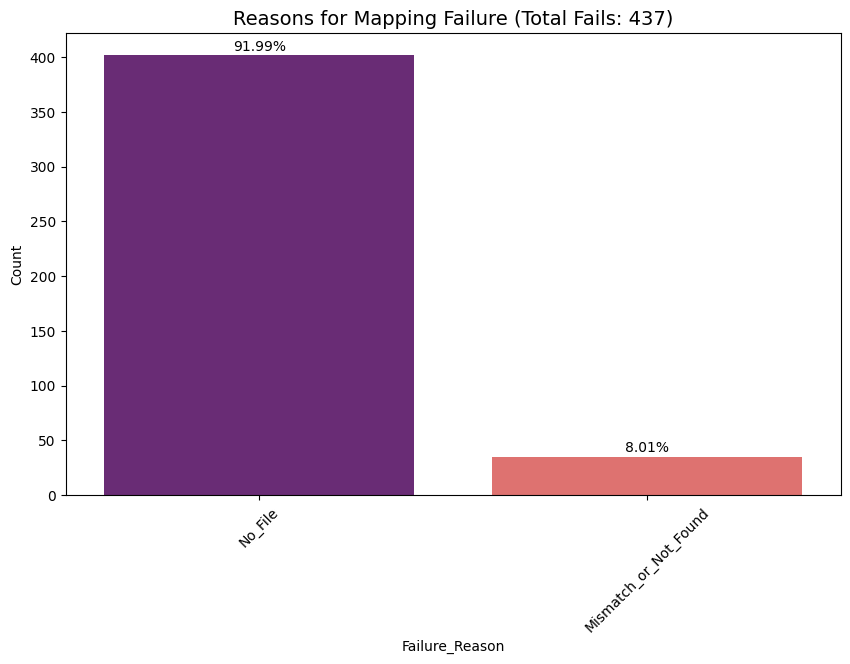

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 실패한 데이터만 추출
df_fail = df_final[df_final["MAPPING_STATUS"] != "Match"].copy()

# 2. 실패 원인별 통계 (Value Counts)
fail_stats = df_fail["MAPPING_STATUS"].value_counts().reset_index()
fail_stats.columns = ['Failure_Reason', 'Count']
fail_stats['Percentage (%)'] = (fail_stats['Count'] / len(df_fail) * 100).round(2)

print("=== [ 매핑 실패 원인 통계 ] ===")
print(fail_stats)
print("-" * 40)

# 3. 주요 원인 분석 가이드
# - No_File: PDB/AlphaFold 다운로드 자체를 실패함 (네트워크 혹은 ID 부재)
# - POS_Not_Found: 구조 파일은 있으나, 해당 POS 번호가 구조 내에 없음 (주로 RCSB PDB의 결실 영역)
# - Mismatch(X): 번호는 있으나 해당 위치의 아미노산이 다름 (주로 RCSB PDB의 번호 밀림 이슈)

# 4. 시각화
plt.figure(figsize=(10, 6))
sns.barplot(data=fail_stats, x='Failure_Reason', y='Count', palette='magma')
plt.title(f"Reasons for Mapping Failure (Total Fails: {len(df_fail)})", fontsize=14)
for i, row in fail_stats.iterrows():
    plt.text(i, row['Count'] + (len(df_fail)*0.01), f"{row['Percentage (%)']}%", ha='center')
plt.xticks(rotation=45)
plt.show()

In [17]:
df_final[(df_final['MAPPING_STATUS'] != 'Match') & (df_final['STRUCTURE_SOURCE'] != 'Failed')]["STRUCTURE_SOURCE"].value_counts()

STRUCTURE_SOURCE
RCSB_PDB     34
AlphaFold     1
Name: count, dtype: int64

In [19]:
df_final[df_final['STRUCTURE_SOURCE'] == 'RCSB_PDB']["MAPPING_STATUS"].value_counts()

MAPPING_STATUS
Mismatch_or_Not_Found    34
Match                    12
Name: count, dtype: int64

In [20]:
df_final[df_final['STRUCTURE_SOURCE'] == 'RCSB_PDB']

,PROTEIN_ID,WT,POS,MUT,DDG_mean,SOURCE_DATASET,UNIPROTKB,PDB_ID,MEGASCALE,UP_ID_CLEAN,FETCHED_ID,STRUCTURE_SOURCE,FILE_PATH,MAPPING_STATUS,MATCHED_CHAIN
1800,P03034,A,50,V,1.22,ProTherm,P03034,3BDN,NaN,P03034,3BDN,RCSB_PDB,./pdb_files\3BDN.pdb,Mismatch_or_Not_Found,None
1801,P03034,A,67,T,2.99,ProTherm,P03034,3BDN,NaN,P03034,3BDN,RCSB_PDB,./pdb_files\3BDN.pdb,Mismatch_or_Not_Found,None
1802,P03034,G,47,A,-0.66,ProTherm,P03034,3BDN,NaN,P03034,3BDN,RCSB_PDB,./pdb_files\3BDN.pdb,Mismatch_or_Not_Found,None
1803,P03034,G,49,A,-0.87,ProTherm,P03034,3BDN,NaN,P03034,3BDN,RCSB_PDB,./pdb_files\3BDN.pdb,Mismatch_or_Not_Found,None
1804,P03034,G,49,N,-0.79,ProTherm,P03034,3BDN,NaN,P03034,3BDN,RCSB_PDB,./pdb_files\3BDN.pdb,Mismatch_or_Not_Found,None
1805,P03034,G,49,S,-0.68,ProTherm,P03034,3BDN,NaN,P03034,3BDN,RCSB_PDB,./pdb_files\3BDN.pdb,Mismatch_or_Not_Found,None
1806,P03034,I,85,S,2.25,ProTherm,P03034,3BDN,NaN,P03034,3BDN,RCSB_PDB,./pdb_files\3BDN.pdb,Mismatch_or_Not_Found,None
1807,P03034,K,5,Q,-0.43,ProTherm,P03034,3BDN,NaN,P03034,3BDN,RCSB_PDB,./pdb_files\3BDN.pdb,Match,A
1808,P03034,M,41,A,2.00,ProTherm,P03034,3BDN,NaN,P03034,3BDN,RCSB_PDB,./pdb_files\3BDN.pdb,Mismatch_or_Not_Found,None
1809,P03034,P,79,A,1.60,ProTherm,P03034,3BDN,NaN,P03034,3BDN,RCSB_PDB,./pdb_files\3BDN.pdb,Mismatch_or_Not_Found,None


In [13]:
df_cleaned = df_final[df_final['MAPPING_STATUS'] == 'Match'].copy()

In [14]:
df_cleaned

,PROTEIN_ID,WT,POS,MUT,DDG_mean,SOURCE_DATASET,UNIPROTKB,PDB_ID,MEGASCALE,UP_ID_CLEAN,FETCHED_ID,STRUCTURE_SOURCE,FILE_PATH,MAPPING_STATUS,MATCHED_CHAIN
0,O26594,V,92,L,1.100000,ProTherm,O26594,NaN,NaN,O26594,O26594,AlphaFold,./pdb_files\O26594_AF.pdb,Match,A
1,O49003,C,450,A,-0.480000,ProTherm,O49003,2V0U,NaN,O49003,O49003,AlphaFold,./pdb_files\O49003_AF.pdb,Match,A
2,O61594,A,263,F,0.430000,ProTherm,O61594,5CG0,NaN,O61594,O61594,AlphaFold,./pdb_files\O61594_AF.pdb,Match,A
3,O61594,D,260,A,0.670000,ProTherm,O61594,5CG0,NaN,O61594,O61594,AlphaFold,./pdb_files\O61594_AF.pdb,Match,A
4,O61594,E,261,A,-0.530000,ProTherm,O61594,5CG0,NaN,O61594,O61594,AlphaFold,./pdb_files\O61594_AF.pdb,Match,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4345,R9S082,T,68,A,0.300000,ProTherm,R9S082,NaN,NaN,R9S082,R9S082,AlphaFold,./pdb_files\R9S082_AF.pdb,Match,A
4346,R9S082,V,115,A,1.400000,ProTherm,R9S082,NaN,NaN,R9S082,R9S082,AlphaFold,./pdb_files\R9S082_AF.pdb,Match,A
4347,R9S082,V,14,A,0.000000,ProTherm,R9S082,NaN,NaN,R9S082,R9S082,AlphaFold,./pdb_files\R9S082_AF.pdb,Match,A
4348,R9S082,V,69,T,0.400000,ProTherm,R9S082,NaN,NaN,R9S082,R9S082,AlphaFold,./pdb_files\R9S082_AF.pdb,Match,A


In [ ]:
import os

# 1. 저장 경로 설정
save_path = os.path.join(r"C:\Users\Kunny\Documents\GitHub\CAGI\EvoStructCLIP\FireProtDB", "df_cleaned_final_not_Mega.csv")

# 2. 파일 저장 (인덱스 제외, UTF-8 인코딩)
df_cleaned.to_csv(save_path, index=False, encoding='utf-8-sig')

print(f"✅ 저장 완료: {save_path}")
print("-" * 50)

# 3. 저장된 데이터 최종 요약
print(f"📂 최종 데이터 로우 수: {len(df_cleaned):,} 개")
print(f"🧬 유니크 단백질(UniProtID) 수: {df_cleaned['UP_ID_CLEAN'].nunique():,} 개")
print(f"구조 출처별 분포:\n{df_cleaned['STRUCTURE_SOURCE'].value_counts()}")
print("-" * 50)

# 4. 제대로 저장됐는지 확인 (상위 5개 샘플 출력)
print("👀 최종 데이터 샘플:")
display(df_cleaned[['UP_ID_CLEAN', 'POS', 'WT', 'PDB_ID', 'MATCHED_CHAIN', 'STRUCTURE_SOURCE']].head())

✅ 저장 완료: C:\Users\Kunny\Documents\GitHub\CAGI\EvoStructCLIP\FireProtDB\df_cleaned_final_not_Mega.csv
--------------------------------------------------
📂 최종 데이터 로우 수: 3,913 개
🧬 유니크 단백질(UniProtID) 수: 173 개
구조 출처별 분포:
STRUCTURE_SOURCE
AlphaFold    3901
RCSB_PDB       12
Name: count, dtype: int64
--------------------------------------------------
👀 최종 데이터 샘플:


,UP_ID_CLEAN,POS,WT,PDB_ID,MATCHED_CHAIN,STRUCTURE_SOURCE
0,O26594,92,V,NaN,A,AlphaFold
1,O49003,450,C,2V0U,A,AlphaFold
2,O61594,263,A,5CG0,A,AlphaFold
3,O61594,260,D,5CG0,A,AlphaFold
4,O61594,261,E,5CG0,A,AlphaFold
